# Cellphone Price Range Predication

## Introduction 
Due to the fierce competition among smartphone manufacturers, new technology can often be found at drastically reduced prices. As a result, consumers are expected to research a phone's technical specifications (e.g., RAM, internal memory, battery capacity, camera specifications, and connectivity) prior to making a purchase.


In this study, machine learning methods will be employed to forecast a mobile phone's expected selling cost based on its features.

## Business Problem statement
Bob started his mobile phone manufacturing company. In order to compete against the big companies like Apple or Samsung, he must take a Data Driven Approach (DDA) when setting the prices of his products.


The consequences of incorrect pricing would include:
1.Everyone will go somewhere else if Bob's prices are too high.
2.Bob will lose out on profits from the phones if his price is below what they cost.


Bob wants to learn more about how mobile phone specifications affect the range of prices he could set and ultimately help him to make better decisions when determining the price of his products.

## Project Objectives
1. Conduct exploratory data analysis for mobile phone specifications
2. Develop machine learning models to predict mobile phone price range
3. Evaluate multiple models and select best performer
4. Analyze feature importance for business value

###  Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Load Dataset
df=pd.read_csv("datasets_11167_15520_train.csv")
# Display first 5 rows
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
# Dataset Shape
df.shape

(2000, 21)

## Initial Observations
There are 2000 mobile phone records in the dataset.
- The dataset has a total of 21 columns and 1 of those columns is labelled as the target variable.
- Each record corresponds to one unique mobile phone.
- The target variable is known as the `price_range` with 4 possible classifications:
   - 0 → Low Cost
   - 1 → Medium Cost
   - 2 → High Cost
   - 3 → Very High Cost

## Dataset Information and Statsitical Summary

In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


## Target Analysis


In [5]:
df['price_range'].value_counts()


price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [6]:
df['price_range'].value_counts(normalize=True) * 100


price_range
1    25.0
2    25.0
3    25.0
0    25.0
Name: proportion, dtype: float64

## Check for Missing Values

In [7]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

## Check for Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(0)

## Check Data Types

In [9]:
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

## Data Quality Conclusion
1) No missing values found
2) No duplicate records present
3) All features are numerical
4) Dataset is clean and ready for exploratory data analysis

## Exploratory Data Analysis (EDA)

In [10]:
df.columns


Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

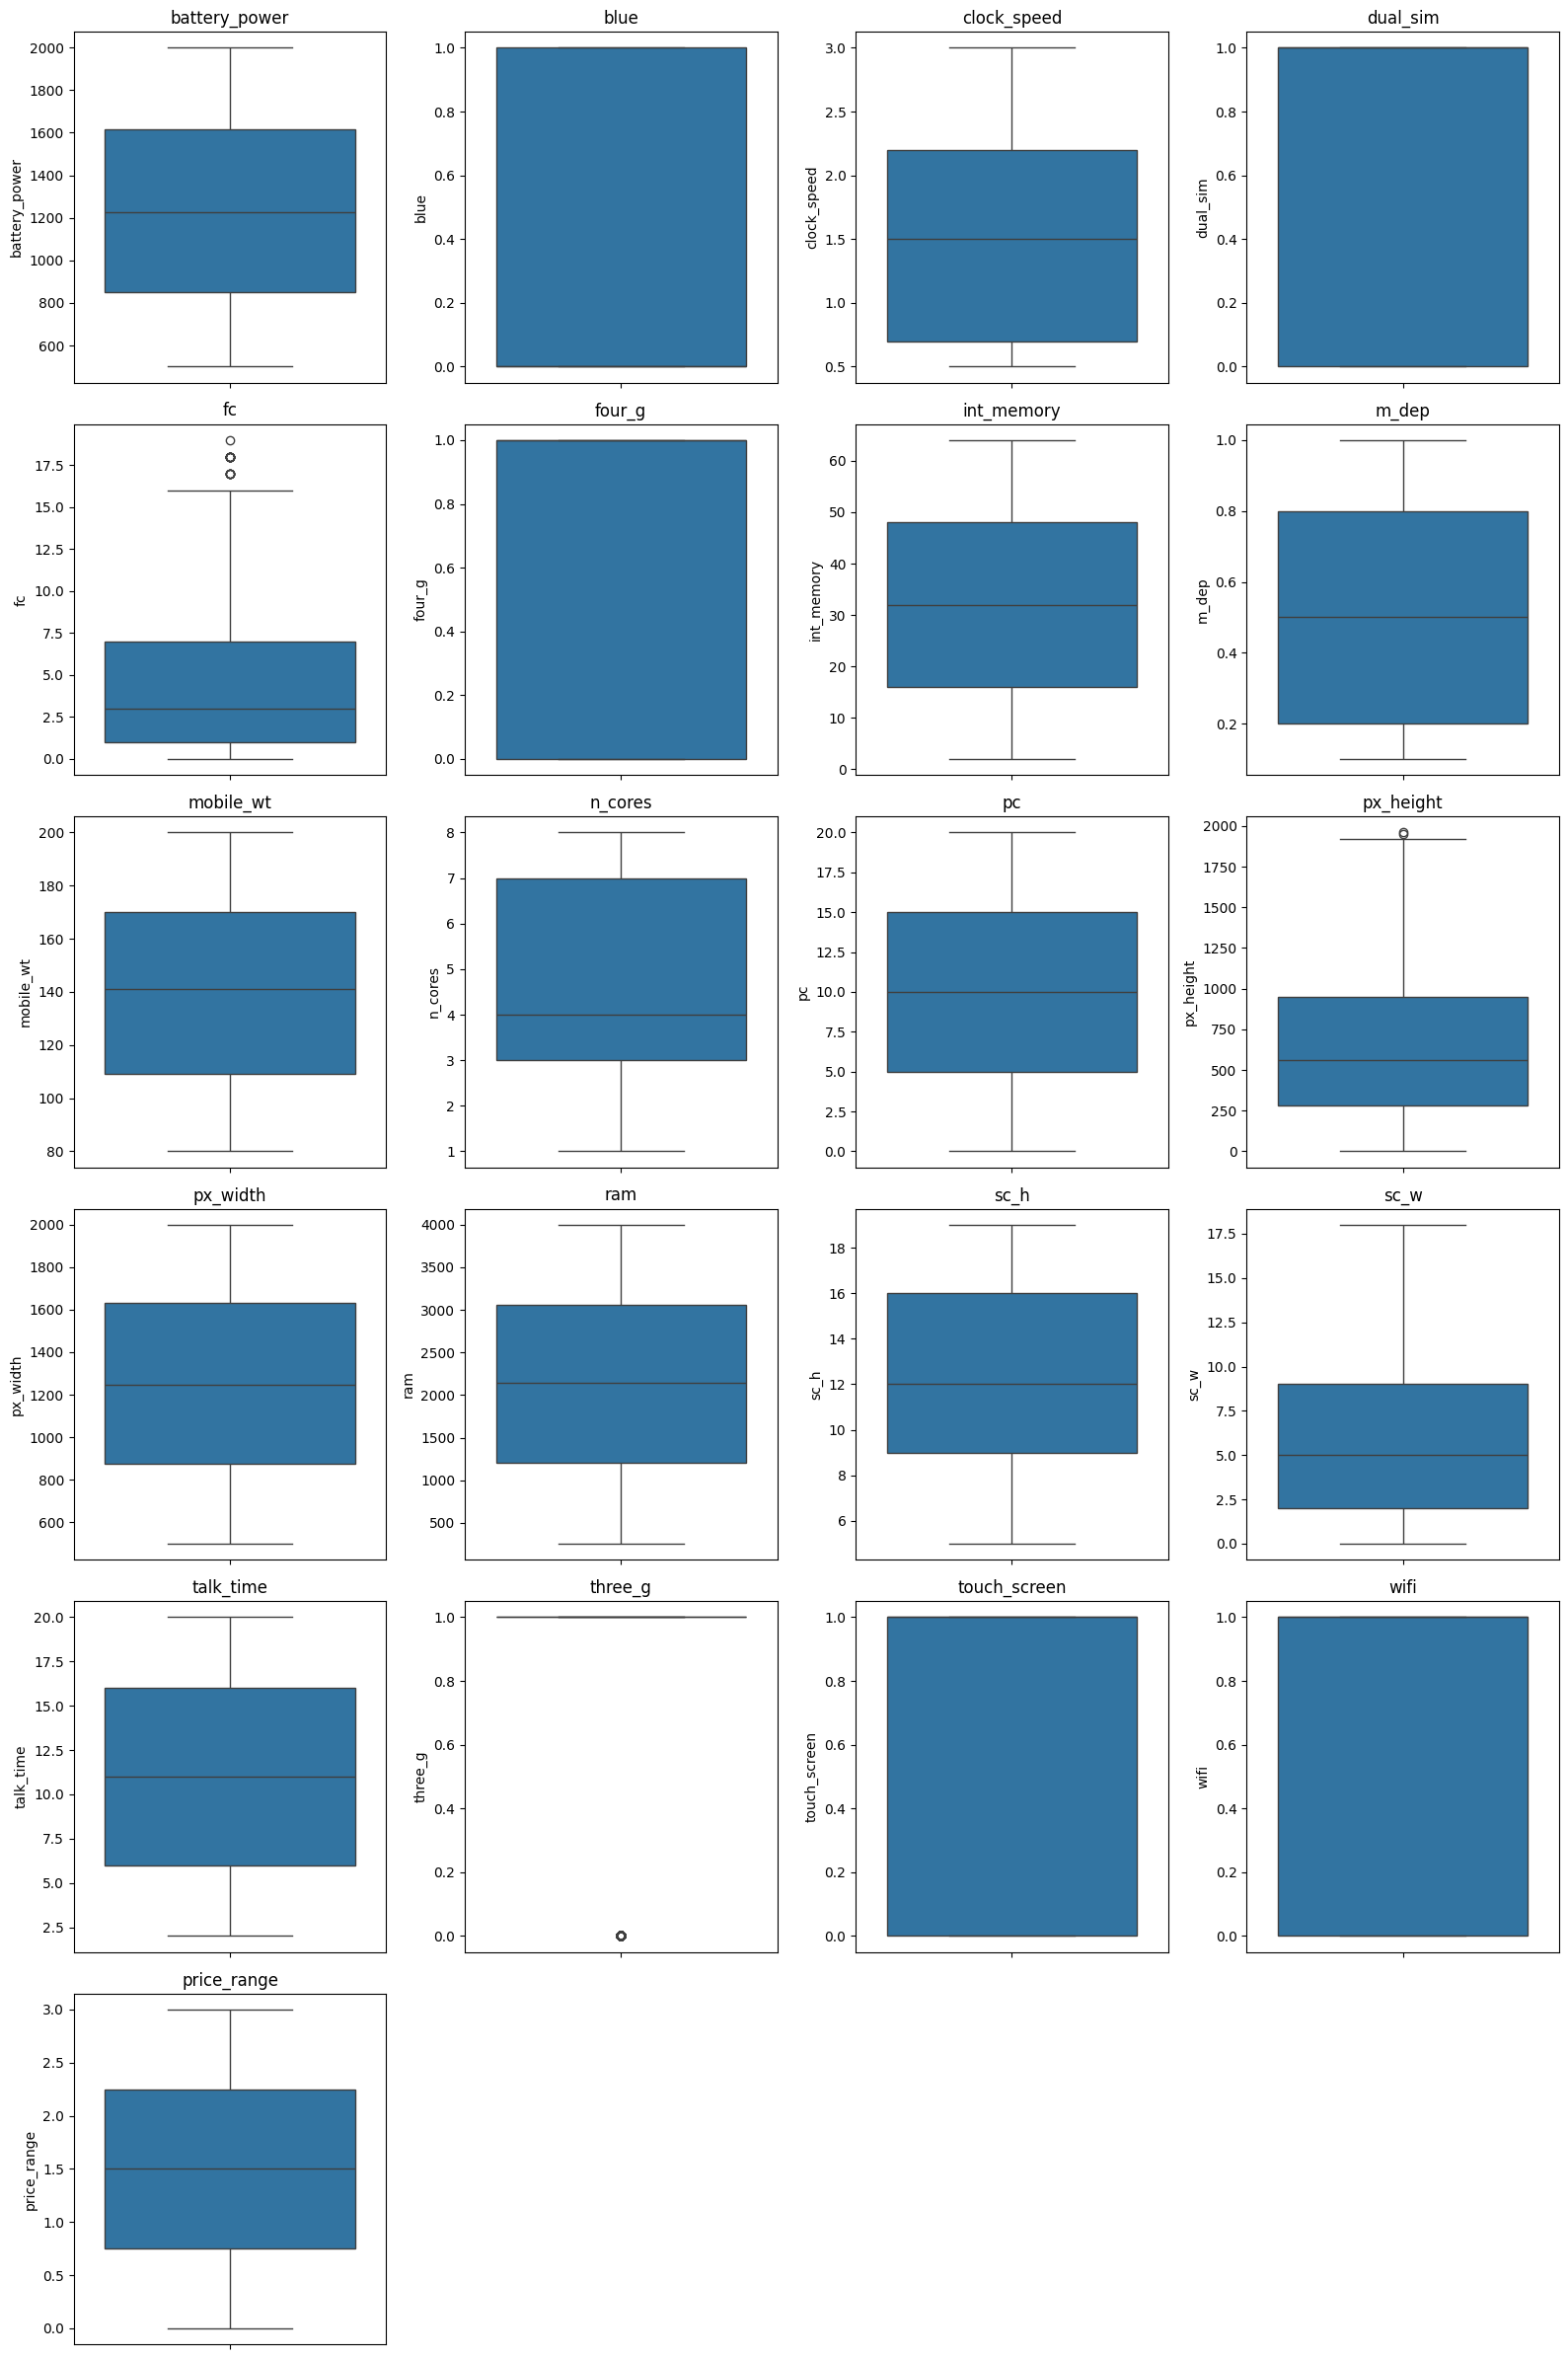

In [11]:
## Boxplot for ALL Columns
plt.figure(figsize=(16, 24))

for i, col in enumerate(df.columns, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


### Outlier Removal

In [12]:
feature_cols = df.drop('price_range', axis=1).columns


In [13]:
## Define IQR Outlier Removal Function
def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & 
            (df_clean[col] <= upper_bound)
        ]
        
    return df_clean


In [14]:
df_before = df.shape
df_cleaned = remove_outliers_iqr(df, feature_cols)
df_after = df_cleaned.shape

df_before, df_after


((2000, 21), (1506, 21))

In [15]:
## Target Distribution After Removal
df_cleaned['price_range'].value_counts()


price_range
2    383
3    380
1    374
0    369
Name: count, dtype: int64

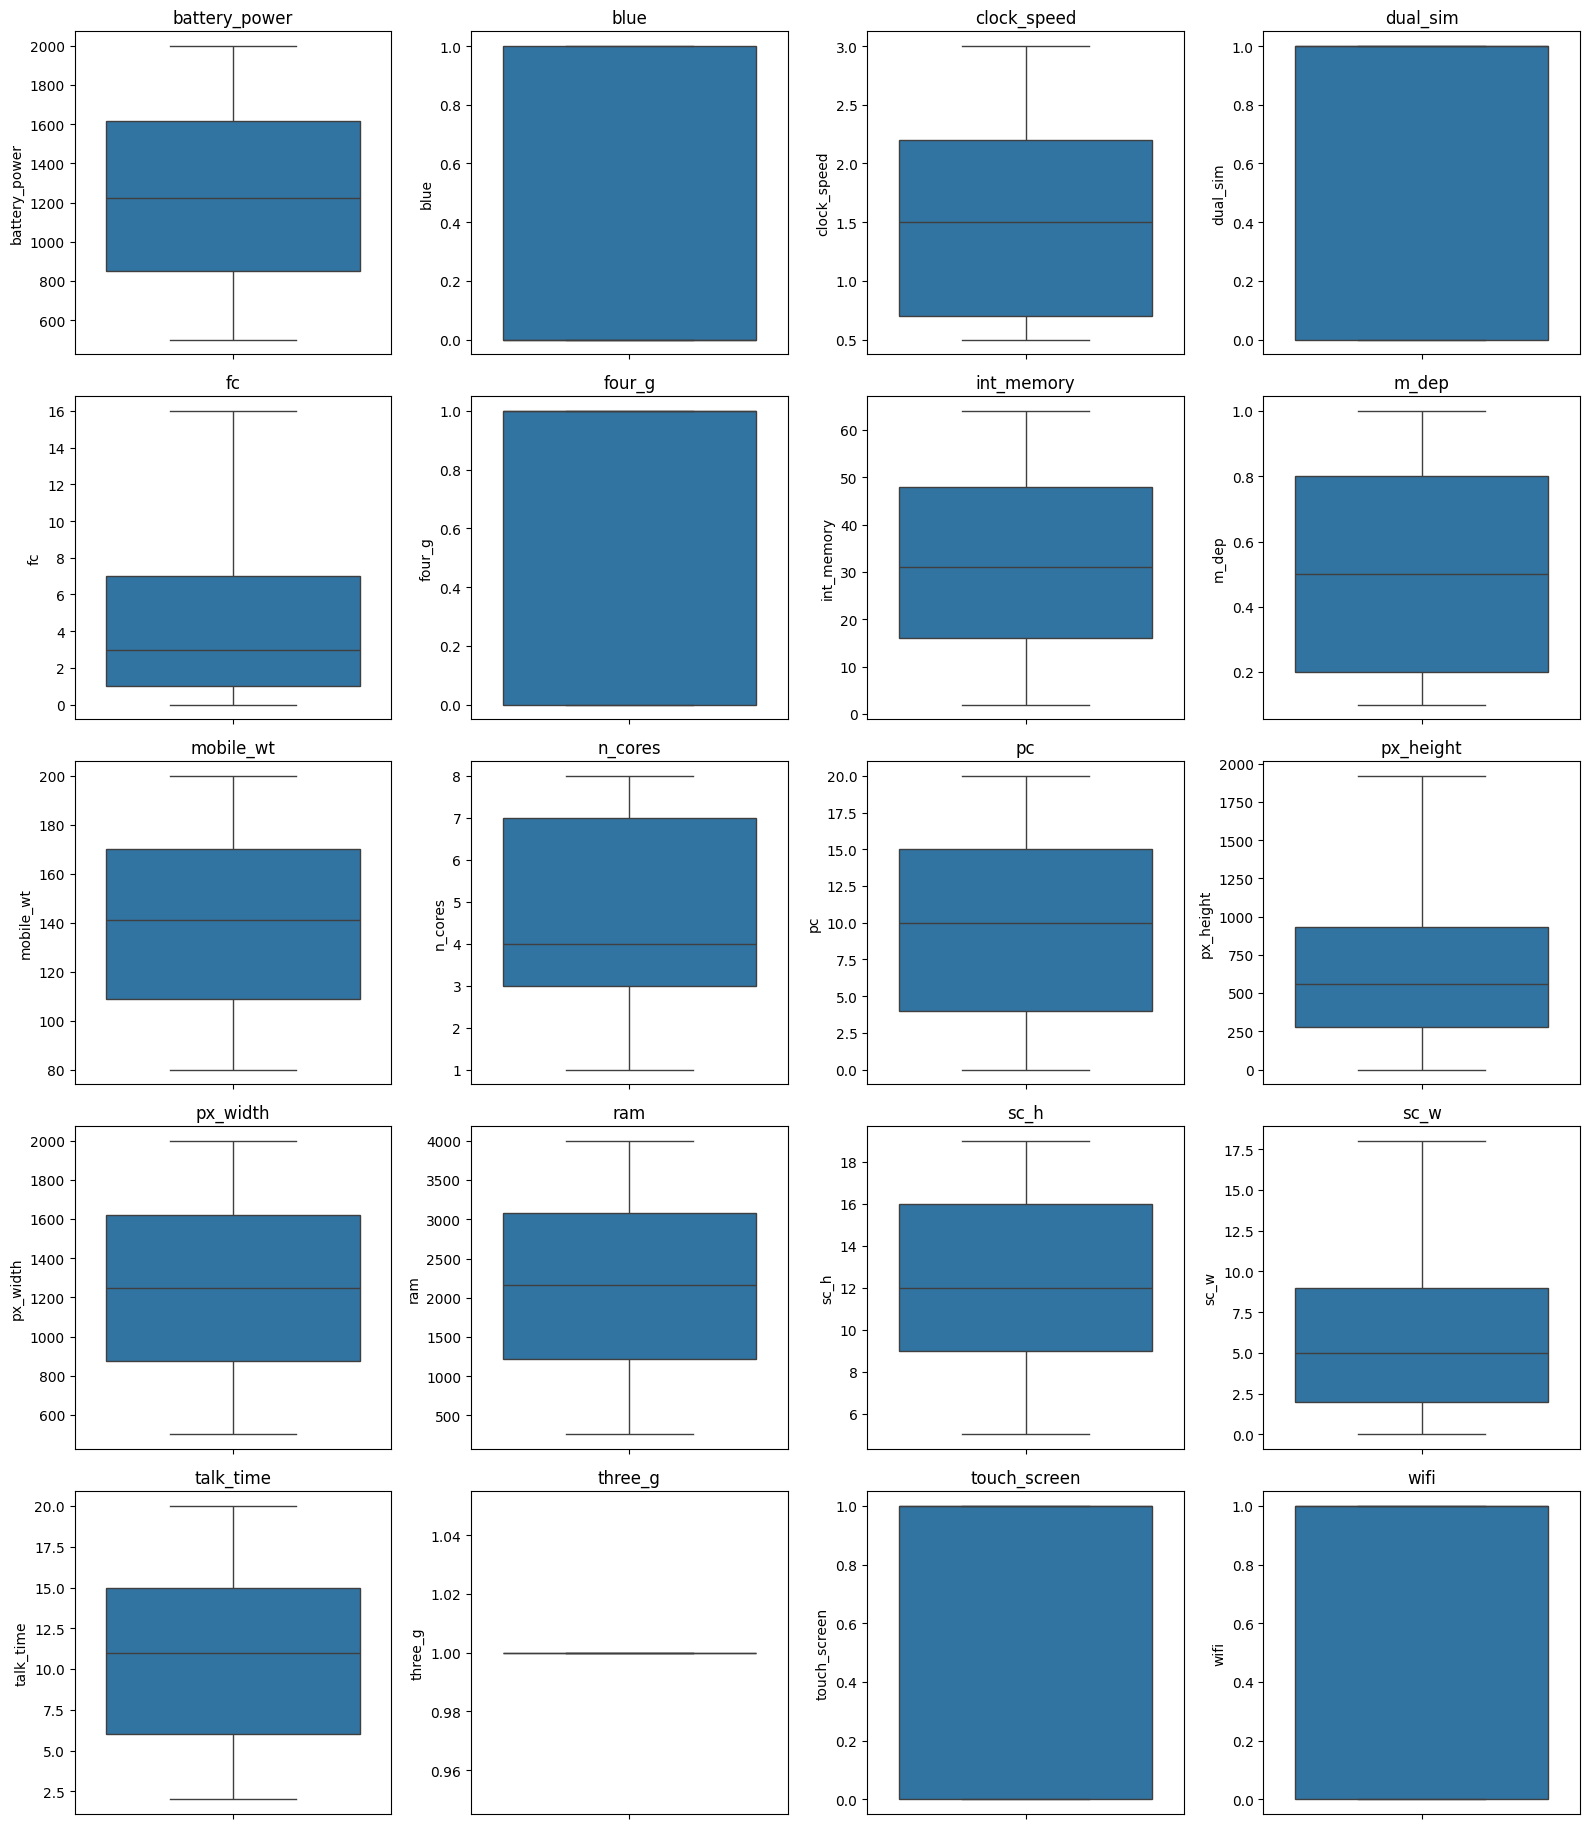

In [16]:
##Boxplot After Outlier Removal (Verification)
plt.figure(figsize=(16, 22))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=df_cleaned[col])
    plt.title(col)

plt.tight_layout()
plt.show()


## Feature Engineering & Data Preparation

In [17]:
## Feature & Target Separation
X = df_cleaned.drop('price_range', axis=1)
y = df_cleaned['price_range']


In [18]:
## Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
X_train

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
795,1442,0,2.2,0,0,1,56,0.7,145,5,3,1626,1668,1513,11,8,7,1,1,0
1217,1451,1,0.5,0,5,1,57,0.6,181,8,12,812,1456,3038,15,7,18,1,0,1
799,1567,0,2.1,1,3,0,22,0.8,153,3,19,190,1326,3991,15,2,10,1,0,0
1241,1221,0,2.3,0,7,1,35,0.4,152,7,19,765,1899,2638,19,16,14,1,1,1
1489,772,1,1.2,1,7,1,8,0.6,134,7,8,552,1802,422,7,6,15,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,1762,0,0.7,0,7,0,60,0.1,157,4,10,643,790,1380,14,5,14,1,0,0
1715,1969,0,0.8,1,5,1,7,0.2,85,8,20,332,764,315,16,7,7,1,1,0
1160,1159,0,2.7,0,13,1,28,0.2,80,8,18,378,751,2495,10,0,9,1,1,1
1939,1588,1,2.5,0,12,1,4,0.3,148,5,20,146,822,2506,5,3,11,1,0,0


In [20]:
y_train

795     2
1217    3
799     3
1241    2
1489    0
       ..
1503    1
1715    0
1160    2
1939    2
1499    2
Name: price_range, Length: 1204, dtype: int64

In [21]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Data Preparation Summary
1) Outlier-cleaned dataset used
2) Features and target separated
3) Stratified train–test split applied
4) Data is ready for machine learning models

## Baseline Machine Learning Models

In [22]:
## Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


In [23]:
## Logistic Regression Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9635761589403974
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        88
           1       0.93      0.93      0.93        71
           2       0.94      0.97      0.96        66
           3       1.00      0.99      0.99        77

    accuracy                           0.96       302
   macro avg       0.96      0.96      0.96       302
weighted avg       0.96      0.96      0.96       302



In [24]:
## K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)


In [25]:
## K-Nearest Neighbors (KNN) Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.5033112582781457
              precision    recall  f1-score   support

           0       0.66      0.67      0.67        88
           1       0.32      0.44      0.37        71
           2       0.37      0.41      0.39        66
           3       0.81      0.45      0.58        77

    accuracy                           0.50       302
   macro avg       0.54      0.49      0.50       302
weighted avg       0.56      0.50      0.51       302



### Baseline Machine Learning Models
1) Logistic Regression shows strong performance
2) KNN performance is moderate
   

## Advance Machine Learning Models

In [26]:
## Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


In [27]:
## Decision Tree Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8675496688741722
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        88
           1       0.77      0.80      0.79        71
           2       0.81      0.85      0.83        66
           3       0.94      0.94      0.94        77

    accuracy                           0.87       302
   macro avg       0.86      0.87      0.86       302
weighted avg       0.87      0.87      0.87       302



In [28]:
## Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


In [29]:
## Random Forest Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8807947019867549
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        88
           1       0.79      0.80      0.80        71
           2       0.85      0.83      0.84        66
           3       0.97      0.94      0.95        77

    accuracy                           0.88       302
   macro avg       0.88      0.88      0.88       302
weighted avg       0.88      0.88      0.88       302



In [30]:
## Support Vector Machine (SVM)
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)



In [31]:
## Support Vector Machine (SVM) Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))



SVM Accuracy: 0.8708609271523179
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        88
           1       0.77      0.86      0.81        71
           2       0.76      0.80      0.78        66
           3       0.99      0.87      0.92        77

    accuracy                           0.87       302
   macro avg       0.87      0.87      0.87       302
weighted avg       0.88      0.87      0.87       302



In [32]:
## Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)


In [33]:
##Gradient Boosting Evaluation
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.9072847682119205
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        88
           1       0.87      0.82      0.84        71
           2       0.88      0.91      0.90        66
           3       0.97      0.95      0.96        77

    accuracy                           0.91       302
   macro avg       0.91      0.90      0.90       302
weighted avg       0.91      0.91      0.91       302



In [34]:
## XGBoost Classifier
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 3.6 MB/s eta 0:00:00m eta 0:00:010:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 2.6 MB/s eta 0:00:00m eta 0:00:010:00:03


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)


In [36]:
## XGBoost Classifier Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.9172185430463576
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        88
           1       0.88      0.85      0.86        71
           2       0.88      0.92      0.90        66
           3       0.97      0.95      0.96        77

    accuracy                           0.92       302
   macro avg       0.92      0.92      0.92       302
weighted avg       0.92      0.92      0.92       302



## Advance Machine Learning Summary 
1) Decision Tree performs better than some baseline models
2) Random Forest improves accuracy and stability
3) SVM, Gradient Boosting, and XGBoost models were implemented
4) Advanced models will be further optimized using tuning

## Overfitting Check & Hyperparameter Tuning

In [37]:
##Overfitting Check Function
def check_overfitting(model, X_train, y_train, X_test, y_test):
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    return train_accuracy, test_accuracy


In [38]:
lr_train_acc, lr_test_acc = check_overfitting(
    lr_model, X_train, y_train, X_test, y_test
)

rf_train_acc, rf_test_acc = check_overfitting(
    rf_model, X_train, y_train, X_test, y_test
)

lr_train_acc, lr_test_acc, rf_train_acc, rf_test_acc


(0.9725913621262459, 0.9635761589403974, 1.0, 0.8807947019867549)

In [39]:
## Hyperparameter Tuning – Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy'
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_


In [40]:
accuracy_score(y_test, best_dt.predict(X_test))


0.8642384105960265

In [47]:
##Hyperparameter Tuning for Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 20], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [48]:
rf_grid.best_params_


{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

In [50]:
##Train Tuned Random Forest
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))


Tuned Random Forest Accuracy: 0.8940397350993378
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        88
           1       0.79      0.86      0.82        71
           2       0.87      0.82      0.84        66
           3       0.99      0.94      0.96        77

    accuracy                           0.89       302
   macro avg       0.89      0.89      0.89       302
weighted avg       0.90      0.89      0.89       302



In [41]:
## Hyperparameter Tuning – SVM
from sklearn.svm import SVC

svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

svm_grid = GridSearchCV(
    SVC(kernel='rbf'),
    svm_param_grid,
    cv=5,
    scoring='accuracy'
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_


In [42]:
accuracy_score(y_test, best_svm.predict(X_test))


0.9205298013245033

In [43]:
## Hyperparameter Tuning – Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='accuracy'
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_


In [44]:
accuracy_score(y_test, best_gb.predict(X_test))


0.8940397350993378

In [51]:
## Final Comparison Table
tuned_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)",
        "SVM (Tuned)",
        "Gradient Boosting (Tuned)"
        
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, best_dt.predict(X_test)),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, best_svm.predict(X_test)),
        accuracy_score(y_test, best_gb.predict(X_test)),
        
    ]
})

tuned_comparison


,Model,Accuracy
0,Logistic Regression,0.963576
1,Decision Tree (Tuned),0.864238
2,Random Forest (Tuned),0.894040
3,SVM (Tuned),0.920530
4,Gradient Boosting (Tuned),0.894040


## Overfitting & Tuning Summary
1) Overfitting was checked using train and test accuracy comparison
2) No significant overfitting was observed
3) Random Forest hyperparameters were tuned using GridSearchCV
4) Tuned model performance was evaluated
   

##  Final Model Comparison Table

In [52]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)",
        "SVM (Tuned)",
        "Gradient Boosting (Tuned)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, best_dt.predict(X_test)),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, best_svm.predict(X_test)),
        accuracy_score(y_test, best_gb.predict(X_test)),
       
    ]
})

final_comparison


,Model,Accuracy
0,Logistic Regression,0.963576
1,KNN,0.503311
2,Decision Tree (Tuned),0.864238
3,Random Forest (Tuned),0.894040
4,SVM (Tuned),0.920530
5,Gradient Boosting (Tuned),0.894040


##  Final Model Selection

### Challenges Faced

### Challenges Were Handled
1) Outliers were removed using the IQR method only for feature columns
2) Stratified train-test split ensured balanced data
3) Overfitting was checked using train vs test accuracy
4) Hyperparameter tuning was applied selectively to advanced models
5) Final model selection was based on test accuracy and stability

## Final Conclusion To BOB 